<a href="https://colab.research.google.com/github/Hyoseok-An/26-1_snubioinformatics/blob/main/Your_own_analysis_(Hyoseok_An)_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LIN28A와 rRNA의 interaction을 보고자 함

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


실습용 Bioconda 환경 설치하기
Google CoLab에서 접속하지 않고, 본인 컴퓨터 또는 연구실 워크스테이션 등 다른 컴퓨터를 쓰시는 경우에는 따로 실습용 Bioconda 환경을 구축해서 이 노트북을 그 환경 안에서 띄우시면 됩니다.

CoLab을 쓰시는 분들은 다음에 따라서 실습용 프로그램들을 쉽게 설치할 수 있도록 Bioconda 환경을 만듭니다. 실행하고 진행상황을 관찰하다가 에러로 보이는 것이 있으면 잘 읽어보고 해결합니다.

파이썬 모듈들은 Colab쪽의 파이썬 인터프리터를 바꿀 수 없기 때문에 Conda에 설치하더라도 사용하기 어렵습니다. 파이썬 모듈은 pip 명령어로 설치하시면 Colab에서 불러와서 사용할 수 있습니다.

환경 초기화에 관련된 스크립트는 GitHub 프로젝트에 있습니다.

In [2]:
!git clone https://github.com/hyeshik/colab-biolab.git
!cd colab-biolab && bash tools/setup.sh
exec(open('colab-biolab/tools/activate_conda.py').read())

Cloning into 'colab-biolab'...
remote: Enumerating objects: 76, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 76 (delta 26), reused 59 (delta 15), pack-reused 0 (from 0)
Receiving objects: 100% (76/76), 318.16 KiB | 3.88 MiB/s, done.
Resolving deltas: 100% (26/26), done.
./
./root/
./root/.tmux.conf
./root/.bashrc.biolab
./root/.profile
./root/.vimrc
./root/.bin.priority/
./root/.bin.priority/pip3
./root/.bin.priority/pip
./root/.bin.priority/pip2
./root/.condarc
--2026-06-12 09:27:14--  https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
Resolving repo.anaconda.com (repo.anaconda.com)... 104.16.191.158, 104.16.32.241, 2606:4700::6810:20f1, ...
Connecting to repo.anaconda.com (repo.anaconda.com)|104.16.191.158|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 163179296 (156M) [application/octet-stream]
Saving to: ‘miniconda3.sh’

miniconda3.sh       100%[===================>] 

In [3]:
!mkdir -p /content/binfo1-mywork
!cp -r /content/drive/MyDrive/binfo1-datapack1/* /content/binfo1-mywork

In [4]:
!pip install pysam
# Conda 환경에 samtools와 gsnap을 직접 설치
!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r
!conda install -c bioconda bowtie2 samtools -y

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 24.2 MB/s eta 0:00:00
accepted Terms of Service for https://repo.anaconda.com/pkgs/main
accepted Terms of Service for https://repo.anaconda.com/pkgs/r
Jupyter detected...
2 channel Terms of Service accepted
Retrieving notices: - \ done
Channels:
 - bioconda
 - conda-forge
 - defaults
Platform: linux-64
Solving environment: \ | / done


==> WARNING: A newer version of conda exists. <==
    current version: 26.3.2
    latest version: 26.5.2

Please update conda by running

    $ conda update -n base -c defaults conda



## Package Plan ##

  environment location: /root/conda

  added / updated specs:
    - bowtie2
    - samtools


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    bowtie2-2.5.5              |       ha27dd3b_0        11.1 MB  bioconda
    ca-certificates-2026.5.20  |       hbd8a1cb_0         127 KB  conda-forge

In [5]:
import os
import subprocess

WORKDIR = "/content/binfo1-mywork"
RRNA_DIR = f"{WORKDIR}/rrna_analysis"
os.makedirs(RRNA_DIR, exist_ok=True)
env = os.environ.copy()
env['PATH'] = f"/usr/local/bin:/opt/conda/bin:{env['PATH']}"

# 1. 레퍼런스 FASTA 다운로드
if not os.path.exists(f"{RRNA_DIR}/mouse_rRNA_ref.fasta"):
    subprocess.run(f"wget -O {RRNA_DIR}/mouse_rRNA_ref.fasta 'https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nucleotide&id=BK000964.1&rettype=fasta&retmode=text'", shell=True)

# 2. CLIP 및 Control BAM에서 Unmapped Reads 추출 (FASTQ)
subprocess.run(f"samtools fastq -f 4 {WORKDIR}/CLIP-35L33G.bam > {RRNA_DIR}/unmapped_CLIP.fastq", shell=True, env=env)
subprocess.run(f"samtools fastq -f 4 {WORKDIR}/RNA-control.bam > {RRNA_DIR}/unmapped_control.fastq", shell=True, env=env)

print("✅ 레퍼런스 다운로드 및 FASTQ 추출 완료!")

✅ 레퍼런스 다운로드 및 FASTQ 추출 완료!


In [6]:
import subprocess
import os

WORKDIR = "/content/binfo1-mywork"
RRNA_DIR = f"{WORKDIR}/rrna_analysis"
env = os.environ.copy()
env['PATH'] = f"/usr/local/bin:/opt/conda/bin:{env['PATH']}"

bash_script = f"""
WORKDIR="{WORKDIR}"
RRNA_DIR="{RRNA_DIR}"

echo "====== 🎯 [Step 1] Index 빌드 시작 ======"
bowtie2-build ${{RRNA_DIR}}/mouse_rRNA_ref.fasta ${{RRNA_DIR}}/rrna_db

echo "====== 🚀 [Step 2] CLIP 데이터 매핑 및 Depth 추출 ======"
bowtie2 -x ${{RRNA_DIR}}/rrna_db -U ${{RRNA_DIR}}/unmapped_CLIP.fastq -S ${{RRNA_DIR}}/lin28a_rrna.sam --local -p 4
samtools view -S -b ${{RRNA_DIR}}/lin28a_rrna.sam | samtools sort -o ${{RRNA_DIR}}/lin28a_rrna_sorted.bam
samtools index ${{RRNA_DIR}}/lin28a_rrna_sorted.bam
samtools depth -a ${{RRNA_DIR}}/lin28a_rrna_sorted.bam > ${{RRNA_DIR}}/clip_depth.txt

echo "====== 🚀 [Step 3] Control 데이터 매핑 및 Depth 추출 ======"
bowtie2 -x ${{RRNA_DIR}}/rrna_db -U ${{RRNA_DIR}}/unmapped_control.fastq -S ${{RRNA_DIR}}/control_rrna.sam --local -p 4
samtools view -S -b ${{RRNA_DIR}}/control_rrna.sam | samtools sort -o ${{RRNA_DIR}}/control_rrna_sorted.bam
samtools index ${{RRNA_DIR}}/control_rrna_sorted.bam
samtools depth -a ${{RRNA_DIR}}/control_rrna_sorted.bam > ${{RRNA_DIR}}/control_depth.txt

echo "✅ 정렬 및 Depth 추출 완전 완료!"
"""

# 수정된 부분: ['bash', '-c', bash_script] 로 스크립트를 정확히 전달합니다. (stdin 파이프 제거)
process = subprocess.Popen(['bash', '-c', bash_script], stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, env=env)

while True:
    output = process.stdout.readline()
    if output == '' and process.poll() is not None:
        break
    if output:
        print(output.strip())

====== 🎯 [Step 1] Index 빌드 시작 ======
Settings:
Output files: "/content/binfo1-mywork/rrna_analysis/rrna_db.*.bt2"
Line rate: 6 (line is 64 bytes)
Lines per side: 1 (side is 64 bytes)
Offset rate: 4 (one in 16)
FTable chars: 10
Strings: unpacked
Max bucket size: default
Max bucket size, sqrt multiplier: default
Max bucket size, len divisor: 4
Difference-cover sample period: 1024
Endianness: little
Actual local endianness: little
Sanity checking: disabled
Assertions: disabled
Random seed: 0
Sizeofs: void*:8, int:4, long:8, size_t:8
Input files DNA, FASTA:
/content/binfo1-mywork/rrna_analysis/mouse_rRNA_ref.fasta
Building a SMALL index
Reading reference sizes
Time reading reference sizes: 00:00:00
Calculating joined length
Writing header
Reserving space for joined string
Joining reference sequences
Time to join reference sequences: 00:00:00
bmax according to bmaxDivN setting: 11327
Using parameters --bmax 8496 --dcv 1024
Doing ahead-of-time memory usage test
Passed!  Constructing with the

In [7]:
import pysam

# Open your main CLIP BAM file
samfile = pysam.AlignmentFile("/content/binfo1-mywork/CLIP-35L33G.bam", "rb")

# Print all reference sequence names (chromosomes) present in the alignment header
print("Chromosomes/Contigs present in BAM:")
for chrom in samfile.references:
    if "rRNA" in chrom or "rnDNA" in chrom or "BK000964" in chrom:
        print(f"-> Found rRNA contig: {chrom}")

# Count total unmapped reads
unmapped_count = samfile.unmapped
print(f"\nTotal unmapped reads in this BAM: {unmapped_count:,}")

Chromosomes/Contigs present in BAM:

Total unmapped reads in this BAM: 2,291,075


In [8]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 37.0 MB/s eta 0:00:00


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

RRNA_DIR = "/content/binfo1-mywork/rrna_analysis"

# 1. samtools depth 결과 불러오기 (컬럼: Chromosome, Position, Depth)
clip_df = pd.read_csv(f"{RRNA_DIR}/clip_depth.txt", sep='\t', header=None, names=['Chrom', 'Position', 'CLIP_Depth'])
control_df = pd.read_csv(f"{RRNA_DIR}/control_depth.txt", sep='\t', header=None, names=['Chrom', 'Position', 'Control_Depth'])

# 2. 데이터 병합
norm_df = pd.merge(clip_df, control_df, on=['Chrom', 'Position'])

# 3. RPM 기반 노멀라이징
TOTAL_CLIP_READS = 169088
TOTAL_CONTROL_READS = 12594234

norm_df["CLIP_RPM"] = (norm_df["CLIP_Depth"] / TOTAL_CLIP_READS) * 1_000_000
norm_df["Control_RPM"] = (norm_df["Control_Depth"] / TOTAL_CONTROL_READS) * 1_000_000

# Enrichment Score 산출 (Pseudocount 1 추가)
norm_df["Enrichment_Score"] = (norm_df["CLIP_RPM"] + 1) / (norm_df["Control_RPM"] + 1)
# 노이즈 필터링
norm_df.loc[norm_df["CLIP_Depth"] < 50, "Enrichment_Score"] = 0

# CSV 저장
norm_df.to_csv(f"{RRNA_DIR}/lin28a_rrna_normalized_scores.csv", index=False)

print("✅ 노멀라이징 및 데이터 통합 완료!")

✅ 노멀라이징 및 데이터 통합 완료!


In [10]:
import pandas as pd
from scipy.signal import find_peaks

def get_rrna_region(pos):
    """
    NCBI GenBank: BK000964.3 (Mouse rDNA complete repeating unit)
    공식 주석(Annotation) 기반 좌표 매핑 함수
    """
    # 1. 45S pre-rRNA 전사체 내부 영역
    if 1 <= pos <= 4007:
        return "5' ETS (External Transcribed Spacer)"
    elif 4008 <= pos <= 5877:
        return "18S rRNA (Small Subunit)"
    elif 5878 <= pos <= 6877:
        return "ITS1 (Internal Transcribed Spacer 1)"
    elif 6878 <= pos <= 7034:
        return "5.8S rRNA"
    elif 7035 <= pos <= 8122:
        return "ITS2 (Internal Transcribed Spacer 2)"
    elif 8123 <= pos <= 12852:
        return "28S rRNA (Large Subunit)"
    elif 12853 <= pos <= 13403:
        return "3' ETS (External Transcribed Spacer)"

    # 2. 유전자 간 스페이서 영역
    elif 13404 <= pos <= 45306:
        return "IGS (Intergenic Spacer)"

    # 3. 예외 처리
    else:
        return "Out of Range (레퍼런스 범위 초과)"


print("=== 🎯 개선된 LIN28A-rRNA 결합 피크 검출 (RPM 정규화 반영) ===\n")

# 1. 이전 단계에서 RPM 정규화까지 마친 norm_df의 Enrichment_Score를 1D 배열로 추출
enrichment_array = norm_df["Enrichment_Score"].values

# 2. find_peaks 모듈을 사용하여 메인 피크만 병합하여 검출
# height: 최소 5배 이상 농축된 곳만 추출 (필요에 따라 조절)
# distance: 50bp 이내에 존재하는 자잘한 봉우리들은 가장 높은 것 딱 1개만 남김
peak_indices, properties = find_peaks(enrichment_array, height=5.0, distance=50)

# 3. 결과 출력 및 모티프 탐색 준비
peaks = []
for idx in peak_indices:
    pos = norm_df.loc[idx, "Position"]
    score = enrichment_array[idx]
    clip_depth = norm_df.loc[idx, "CLIP_Depth"]
    peaks.append((pos, score, clip_depth))

# Score가 높은 순으로 정렬
peaks = sorted(peaks, key=lambda x: x[1], reverse=True)

for rank, (pos, score, depth) in enumerate(peaks[:5], 1):
    region_name = get_rrna_region(pos)
    print(f"📍 [Peak {rank}] 좌표: {pos:,} bp | Enrichment Score: {score:.2f}배 | CLIP Depth: {depth:,}")
    print(f"   🧬 리보솜 유전자 위치: {region_name}")
    print("-" * 70)

=== 🎯 개선된 LIN28A-rRNA 결합 피크 검출 (RPM 정규화 반영) ===

📍 [Peak 1] 좌표: 24,589 bp | Enrichment Score: 1084.69배 | CLIP Depth: 591
   🧬 리보솜 유전자 위치: IGS (Intergenic Spacer)
----------------------------------------------------------------------
📍 [Peak 2] 좌표: 2,392 bp | Enrichment Score: 484.78배 | CLIP Depth: 13,984
   🧬 리보솜 유전자 위치: 5' ETS (External Transcribed Spacer)
----------------------------------------------------------------------
📍 [Peak 3] 좌표: 6,478 bp | Enrichment Score: 465.56배 | CLIP Depth: 2,185
   🧬 리보솜 유전자 위치: ITS1 (Internal Transcribed Spacer 1)
----------------------------------------------------------------------
📍 [Peak 4] 좌표: 39,889 bp | Enrichment Score: 308.03배 | CLIP Depth: 85
   🧬 리보솜 유전자 위치: IGS (Intergenic Spacer)
----------------------------------------------------------------------
📍 [Peak 5] 좌표: 6,938 bp | Enrichment Score: 293.93배 | CLIP Depth: 25,424
   🧬 리보솜 유전자 위치: 5.8S rRNA
----------------------------------------------------------------------


RPM normalization을 반영하여 보고자 하는 rRNA의 위치를 정하고 이것이 LIN28A와 관련하여 biological important feature인지 validation 하고자 한다.
1. [peak 5] CLIP Depth : 25,424인 5.8S rRNA 6,938bp

2. [peak 2] CLIP Depth : 13,984인 5' ETS rRNA 2,392bp

**1. [peak 5] CLIP Depth : 25,424인 5.8S rRNA 6,938bp**

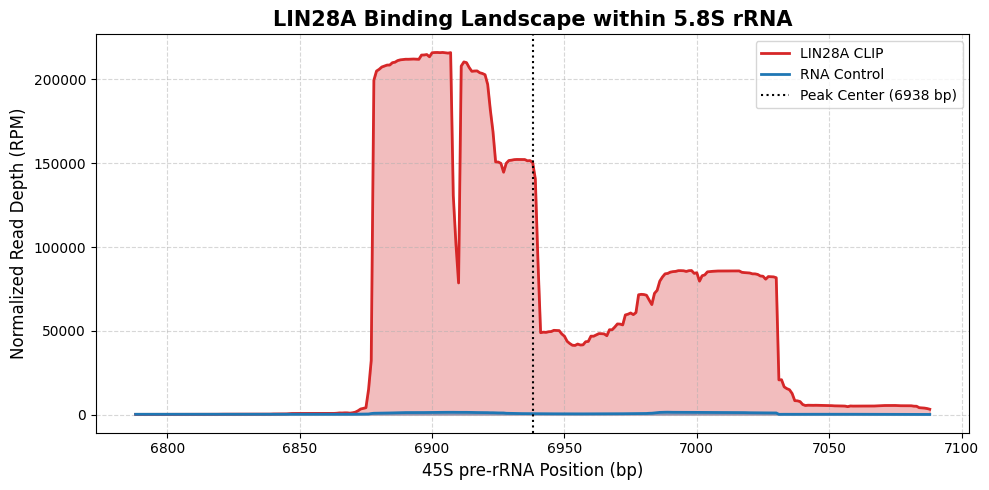

In [54]:
import matplotlib.pyplot as plt

# 1. 5.8S rRNA 핫스팟 (6,938 bp) 주변 150bp (총 300bp 구간) 확대
peak_center = 6938
window = 150
zoom_df = norm_df[(norm_df['Position'] >= peak_center - window) & (norm_df['Position'] <= peak_center + window)]

# 2. 그래프 그리기
plt.figure(figsize=(10, 5))

# CLIP vs Control RPM 비교 플롯
plt.plot(zoom_df['Position'], zoom_df['CLIP_RPM'], label='LIN28A CLIP', color='#D62728', linewidth=2)
plt.plot(zoom_df['Position'], zoom_df['Control_RPM'], label='RNA Control', color='#1F77B4', linewidth=2)

# 곡선 아래 면적 색칠하기
plt.fill_between(zoom_df['Position'], zoom_df['CLIP_RPM'], alpha=0.3, color='#D62728')
plt.fill_between(zoom_df['Position'], zoom_df['Control_RPM'], alpha=0.3, color='#1F77B4')

# 핫스팟 중앙선 표시
plt.axvline(peak_center, color='black', linestyle=':', linewidth=1.5, label=f'Peak Center ({peak_center} bp)')

# 그래프 꾸미기
plt.title(f"LIN28A Binding Landscape within 5.8S rRNA", fontsize=15, fontweight='bold')
plt.xlabel("45S pre-rRNA Position (bp)", fontsize=12)
plt.ylabel("Normalized Read Depth (RPM)", fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [12]:
# 이미 상단에서 세팅된 환경을 사용하여 RNA 2차 구조 예측 툴 설치
import os
import subprocess

env = os.environ.copy()
env['PATH'] = f"/usr/local/bin:/opt/conda/bin:{env['PATH']}"

print("📦 ViennaRNA 및 시각화 도구 설치 중...")
subprocess.run("conda install -y -c bioconda viennarna", shell=True, env=env)
subprocess.run("conda install -y -c conda-forge ghostscript biopython", shell=True, env=env)
print("✅ 설치 완료!")

📦 ViennaRNA 및 시각화 도구 설치 중...
✅ 설치 완료!


In [24]:
import pandas as pd

# 1. 5.8S rRNA 전체 서열 추출 (6878 ~ 7034bp, 1-based)
start_pos = 6878
end_pos = 7034
s58_seq = rrna_seq[start_pos-1 : end_pos].replace('T', 'U')

# 2. 논문(Panel B)의 Top 10 LIN28A-interacting hexamers
paper_hexamers = {
    'AAGGAG': 8.03, 'AAGGUG': 3.91, 'AAGAGG': 3.76, 'AAGAAG': 3.61,
    'AAGAGA': 2.49, 'AAGAGC': 2.11, 'AAGCAG': 2.00, 'AAGUGG': 1.69,
    'AAGAGU': 1.53, 'GAGGAG': 1.44
}

matches_mismatch2 = []
window_size = 6

for i in range(len(s58_seq) - window_size + 1):
    hexamer = s58_seq[i:i+window_size]
    actual_pos = start_pos + i

    for motif, freq in paper_hexamers.items():
        mismatch = sum(1 for a, b in zip(hexamer, motif) if a != b)

        if mismatch <= 2:
            status = '⭐ Exact' if mismatch == 0 else ('🔹 1-nt Var' if mismatch == 1 else '🔸 2-nt Var')
            matches_mismatch2.append({
                'Position': actual_pos,
                'Hexamer': hexamer,
                'Paper_Motif': motif,
                'Mismatch': mismatch,
                'Frequency(%)': freq,
                'Status': status
            })

df_motifs_m2 = pd.DataFrame(matches_mismatch2)

if not df_motifs_m2.empty:
    # 💡 [수정된 부분] 정렬 기준 변경: 1순위 Mismatch(오름차순), 2순위 Frequency(내림차순)
    df_motifs_m2 = df_motifs_m2.sort_values(
        by=['Mismatch', 'Frequency(%)', 'Position'],
        ascending=[True, False, True]
    )

    # 중복 제거 (가장 완벽하고 빈도가 높은 모티프만 남김)
    df_motifs_m2 = df_motifs_m2.drop_duplicates(subset=['Position'])

    print(f"\n✅ [Mismatch 2 허용] 총 {len(df_motifs_m2)}개의 모티프 유사 서열이 발견되었습니다.\n")
    display(df_motifs_m2)
else:
    print("❌ 매칭되는 모티프가 없습니다.")


✅ [Mismatch 2 허용] 총 21개의 모티프 유사 서열이 발견되었습니다.



,Position,Hexamer,Paper_Motif,Mismatch,Frequency(%),Status
30,6941,AAUGUG,AAGGUG,1,3.91,🔹 1-nt Var
10,6913,AUGAAG,AAGAAG,1,3.61,🔹 1-nt Var
15,6916,AAGAAC,AAGAAG,1,3.61,🔹 1-nt Var
22,6920,ACGCAG,AAGCAG,1,2.00,🔹 1-nt Var
36,6952,CAGGAC,AAGGAG,2,8.03,🔸 2-nt Var
3,6886,GCGGUG,AAGGUG,2,3.91,🔸 2-nt Var
23,6927,UAGCUG,AAGGUG,2,3.91,🔸 2-nt Var
0,6884,UAGCGG,AAGAGG,2,3.76,🔸 2-nt Var
26,6934,GAGAAU,AAGAAG,2,3.61,🔸 2-nt Var
25,6932,GCGAGA,AAGAGA,2,2.49,🔸 2-nt Var


**[peak 2] CLIP Depth : 13,984인 5' ETS rRNA 2,392bp**

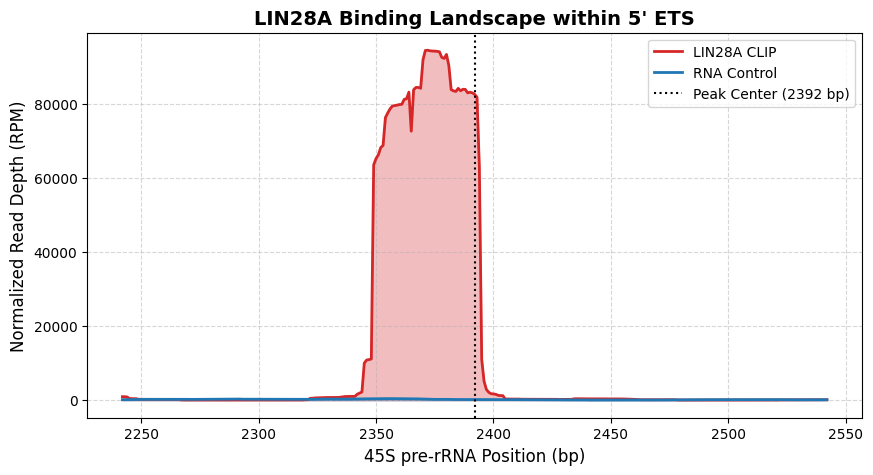

In [55]:
import matplotlib.pyplot as plt

# 2,392 bp 주변 150bp 확대 (총 300bp 구간)
peak_center = 2392
window = 150
zoom_df = norm_df[(norm_df['Position'] >= peak_center - window) & (norm_df['Position'] <= peak_center + window)]

plt.figure(figsize=(10, 5))
plt.plot(zoom_df['Position'], zoom_df['CLIP_RPM'], label='LIN28A CLIP', color='#D62728', linewidth=2)
plt.plot(zoom_df['Position'], zoom_df['Control_RPM'], label='RNA Control', color='#1F77B4', linewidth=2)
plt.fill_between(zoom_df['Position'], zoom_df['CLIP_RPM'], alpha=0.3, color='#D62728')
plt.fill_between(zoom_df['Position'], zoom_df['Control_RPM'], alpha=0.3, color='#1F77B4')
plt.axvline(peak_center, color='black', linestyle=':', linewidth=1.5, label=f'Peak Center ({peak_center} bp)')

plt.title(f"LIN28A Binding Landscape within 5' ETS", fontsize=14, fontweight='bold')
plt.xlabel("45S pre-rRNA Position (bp)", fontsize=12)
plt.ylabel("Normalized Read Depth (RPM)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [27]:
import pandas as pd
from collections import Counter

def discover_de_novo_motifs(target_df, label_name, top_q=0.90, flank=5, window_size=6):
    """
    Enrichment Peak 서열들로부터 외부 데이터 없이 자체 모티프를 발굴하는 함수
    """
    # 1. 해당 구간 내 상위 10% (또는 지정된 컷오프) Peak 선별
    threshold = target_df['Enrichment_Score'].quantile(top_q)
    peaks = target_df[target_df['Enrichment_Score'] >= threshold]

    all_hexamers = []

    # 2. Peak 주변 서열(flank)에서 모든 Hexamer 추출하여 수집
    for idx, row in peaks.iterrows():
        pos = int(row['Position'])

        start_idx = max(0, pos - 1 - flank)
        end_idx = min(len(rrna_seq), pos - 1 + flank + 1)
        peak_subseq = rrna_seq[start_idx:end_idx].replace('T', 'U')

        # 6bp 슬라이딩하며 모든 서열 카운트 대상으로 등록
        for i in range(len(peak_subseq) - window_size + 1):
            hexamer = peak_subseq[i:i+window_size]
            if len(hexamer) == window_size:
                all_hexamers.append(hexamer)

    # 3. 빈도수 계산 및 데이터프레임화
    counts = Counter(all_hexamers)
    total_counts = sum(counts.values())

    df_motifs = pd.DataFrame(counts.items(), columns=['Sequence', 'Count'])
    df_motifs['Frequency (%)'] = (df_motifs['Count'] / total_counts) * 100

    # 가장 많이 등장한 순서대로 정렬하여 Top 10 추출
    df_motifs = df_motifs.sort_values(by='Count', ascending=False).head(10).reset_index(drop=True)

    print(f"📊 [{label_name}] (Score 컷오프: {threshold:.2f}, 분석된 Peak: {len(peaks)}개)")
    return df_motifs

# ---------------------------------------------------------------------------
# [실행 1] 5.8S rRNA 구간 데이터 준비 및 자체 모티프 분석
s58_df = norm_df[(norm_df['Position'] >= 6878) & (norm_df['Position'] <= 7034)]
df_s58_de_novo = discover_de_novo_motifs(s58_df, "5.8S rRNA De Novo Motifs")
display(df_s58_de_novo)
print("\n" + "="*50 + "\n")

# [실행 2] 5' ETS 구간 데이터 준비 및 자체 모티프 분석
ets_df = norm_df[(norm_df['Position'] >= 1) & (norm_df['Position'] <= 4000)]
df_ets_de_novo = discover_de_novo_motifs(ets_df, "5' ETS De Novo Motifs")
display(df_ets_de_novo)
print("\n" + "="*50 + "\n")

# [실행 3] 전체 pre-rRNA 전장 데이터 준비 및 자체 모티프 분석
# (전체 전장은 데이터가 많으므로 상위 5% 최상위 피크로 엄격하게 타겟팅)
df_full_de_novo = discover_de_novo_motifs(norm_df, "Full-length pre-rRNA De Novo Motifs", top_q=0.95)
display(df_full_de_novo)

📊 [5.8S rRNA De Novo Motifs] (Score 컷오프: 206.44, 분석된 Peak: 16개)


,Sequence,Count,Frequency (%)
0,ACUCUU,6,6.250000
1,GACUCU,6,6.250000
2,GCGAGA,6,6.250000
3,CGAGAA,6,6.250000
4,GAGAAU,6,6.250000
5,UGCGAG,6,6.250000
6,CUCUUA,5,5.208333
7,CGACUC,5,5.208333
8,CUGCGA,5,5.208333
9,AGAAUU,5,5.208333




📊 [5' ETS De Novo Motifs] (Score 컷오프: 13.45, 분석된 Peak: 400개)


,Sequence,Count,Frequency (%)
0,UUUUUU,174,7.250000
1,GGGGGG,30,1.250000
2,UCCCGA,24,1.000000
3,UCUUUU,24,1.000000
4,CUUUUU,23,0.958333
5,GUCCCG,19,0.791667
6,UUUCUU,18,0.750000
7,UUCUUU,18,0.750000
8,UUUUCU,18,0.750000
9,GUGGUG,16,0.666667




📊 [Full-length pre-rRNA De Novo Motifs] (Score 컷오프: 14.72, 분석된 Peak: 2266개)


,Sequence,Count,Frequency (%)
0,CUCUCU,264,1.941748
1,UCUCUC,263,1.934392
2,UUUUUU,237,1.743160
3,GGGGGG,66,0.485437
4,UCCCGA,47,0.345690
5,UUUCUU,43,0.316269
6,AAGAAG,40,0.294204
7,GAAGAA,40,0.294204
8,UCUUUC,39,0.286849
9,UUCUUU,37,0.272139


📍 Peak 2392bp 주변의 5' ETS 서열 (61bp):
5'- UCAGGGGAGUGGUGCAGUGUGAUUCCCGCCGGUUUUGCCUCGCGUGCCCUGACCGGUCCGA -3'

결과 (Dot-Bracket): ....((((((...........))))))(((((((..(((....).))...)))))))....
Minimum Free Energy (MFE): (-18.30)

==== 🧬 LIN28A Binding Site RNA 2차 구조 ====


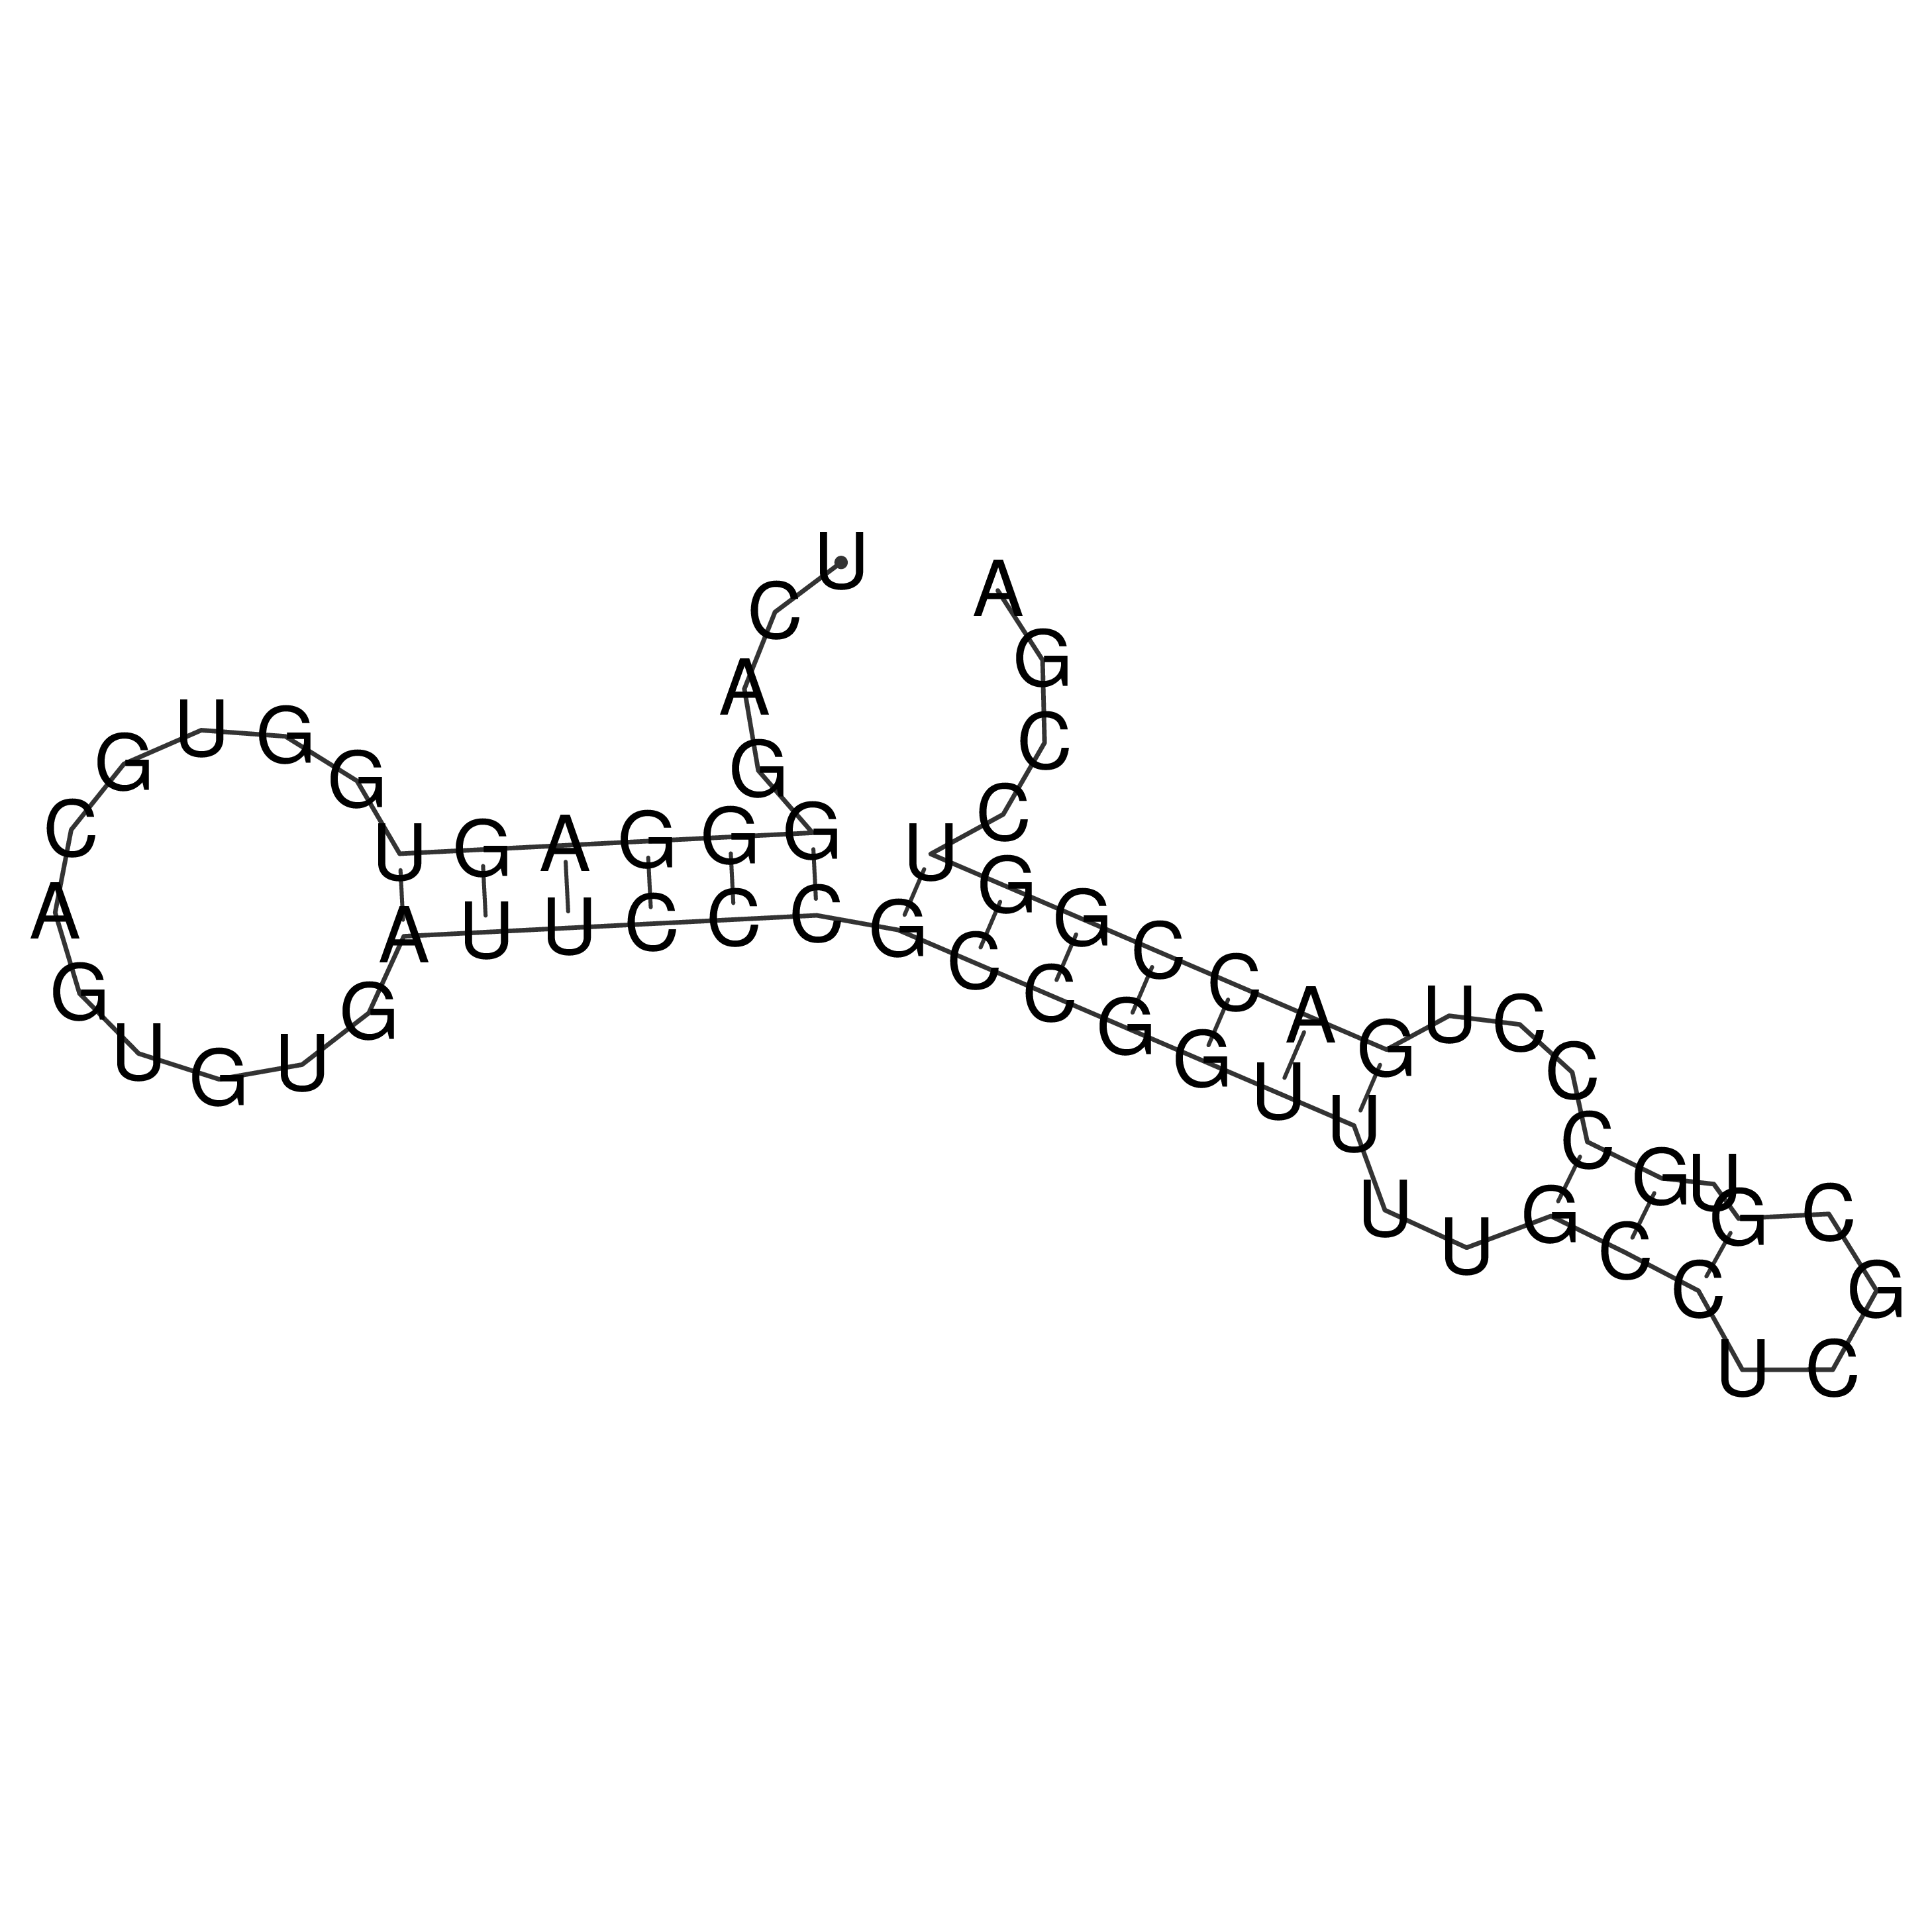

In [16]:
# 2,392 bp 정확한 서열 추출
target_pos = 2392
target_idx = target_pos - 1
window = 30 # 주변 61bp 추출

subseq_dna = rrna_seq[target_idx - window : target_idx + window + 1]
subseq_rna = subseq_dna.replace("T", "U")

print(f"📍 Peak {target_pos}bp 주변의 5' ETS 서열 (61bp):\n5'- {subseq_rna} -3'\n")

# 구조 분석 실행
analyze_rna_structure(subseq_rna, title=f"LIN28A Binding Site at 5' ETS ({target_pos}bp)")

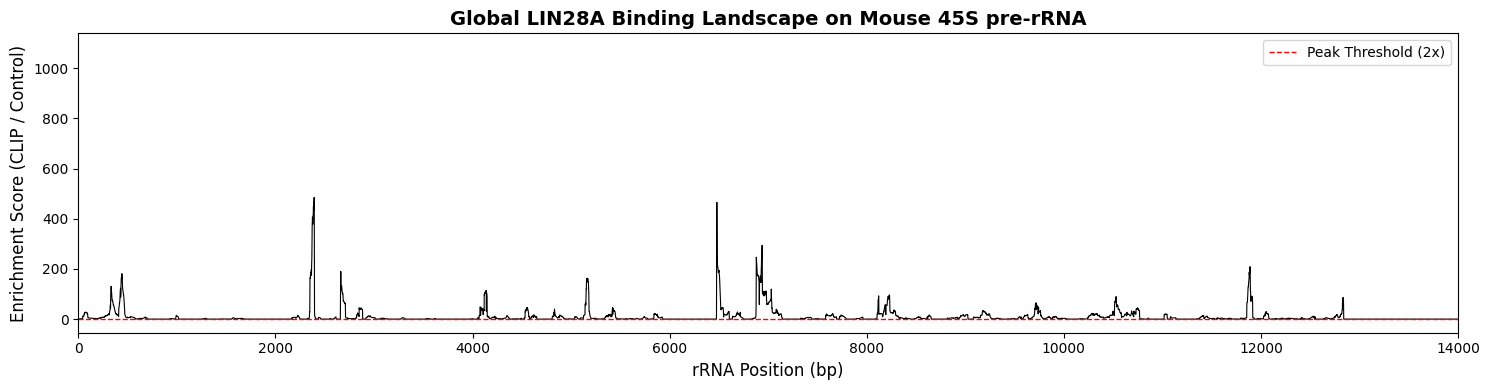

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))
# 전체 영역에 대해 Enrichment Score 플롯
plt.plot(norm_df['Position'], norm_df['Enrichment_Score'], color='black', linewidth=0.8)

plt.axhline(y=2, color='red', linestyle='--', linewidth=1, label='Peak Threshold (2x)')
plt.title("Global LIN28A Binding Landscape on Mouse 45S pre-rRNA", fontsize=14, fontweight='bold')
plt.xlabel("rRNA Position (bp)", fontsize=12)
plt.ylabel("Enrichment Score (CLIP / Control)", fontsize=12)
plt.xlim(0, 14000) # 주요 전사체 구간(45S)만 확대해서 보기
plt.legend()
plt.tight_layout()
plt.show()

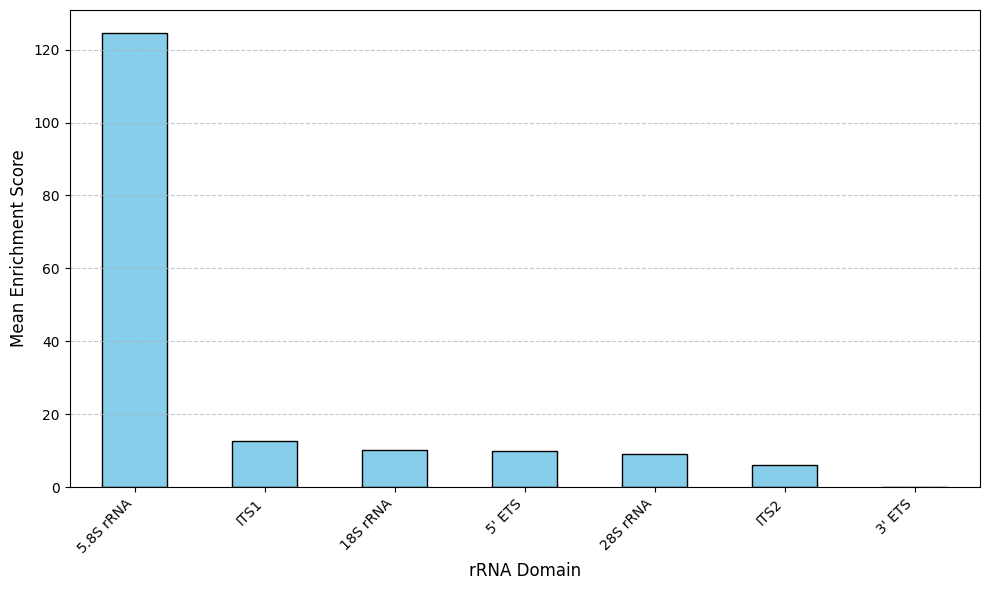

In [48]:
# 1. 도메인 이름을 영문으로 매핑하는 함수로 수정
def get_rrna_region_en(pos):
    if 1 <= pos <= 4007: return "5' ETS"
    elif 4008 <= pos <= 5877: return "18S rRNA"
    elif 5878 <= pos <= 6877: return "ITS1"
    elif 6878 <= pos <= 7034: return "5.8S rRNA"
    elif 7035 <= pos <= 8122: return "ITS2"
    elif 8123 <= pos <= 12852: return "28S rRNA"
    elif 12853 <= pos <= 13403: return "3' ETS"
    else: return "Other" # IGS 및 Out of Range 통합

# 2. 적용 및 필터링
norm_df['Domain'] = norm_df['Position'].apply(get_rrna_region_en)
clean_df = norm_df[norm_df['Domain'] != 'Other']

# 3. 도메인별 계산 및 시각화
domain_distribution = clean_df.groupby('Domain')['Enrichment_Score'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
domain_distribution.plot(kind='bar', color='skyblue', edgecolor='black')

plt.xlabel("rRNA Domain", fontsize=12)
plt.ylabel("Mean Enrichment Score", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**만약 LIN28A가 ribosome biogenesis의 역할로 rRNA와 interaction하는거라면 왜이렇게 다른 rRNA component 대비 enrich되어있을까? cytosolic function이 있지는 않을까?**

✅ 예측된 구조 (길이: 157bp): (((.((((((((((.........((..(((...


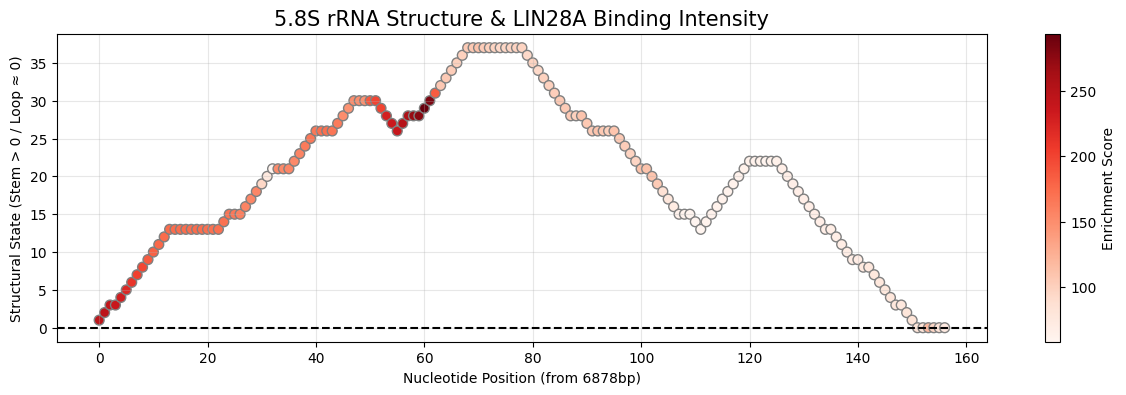


[📊 Stem vs Loop 평균 결합 점수 비교]
Type
Loop    127.039901
Stem    123.293176
Name: Score, dtype: float64


In [20]:
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# 1. 5.8S rRNA 서열 추출 (6,878bp ~ 7,034bp, 1-based)
start_pos = 6878
end_pos = 7034
s58_seq = rrna_seq[start_pos-1 : end_pos].replace('T', 'U')

# 2. RNAfold로 구조 예측 (dot-bracket 표기)
process = subprocess.run(['RNAfold', '--noPS'], input=s58_seq, text=True, capture_output=True)
output = process.stdout.strip().split('\n')
if len(output) >= 2:
    structure = output[1].split(' ')[0]
    print(f"✅ 예측된 구조 (길이: {len(structure)}bp): {structure[:30]}...")
else:
    print("❌ RNAfold 실행 실패. 설치를 확인하세요.")
    structure = "." * len(s58_seq) # 실패 시 임시 구조

# 3. 데이터 매핑 (Enrichment Score 매칭)
s58_scores = norm_df[(norm_df['Position'] >= start_pos) & (norm_df['Position'] <= end_pos)]['Enrichment_Score'].values

mapping = []
for i, (s, score) in enumerate(zip(structure, s58_scores)):
    region_type = "Stem" if s in ['(', ')'] else "Loop"
    mapping.append({'Position': i + start_pos, 'Structure': s, 'Type': region_type, 'Score': score})

df_mapping = pd.DataFrame(mapping)

# 4. 구조 정보를 가상의 2D 좌표로 변환
def get_structure_coords(struct_str):
    coords = []
    x = 0
    for char in struct_str:
        if char == '(': x += 1
        elif char == ')': x -= 1
        coords.append(x)
    return coords

coords = get_structure_coords(structure)
scores = df_mapping['Score'].values

# 5. 시각화: 구조 좌표와 결합 점수를 Heatmap처럼 표현
plt.figure(figsize=(15, 4))
sc = plt.scatter(range(len(coords)), coords, c=scores, cmap='Reds', s=50, edgecolors='gray')
plt.colorbar(sc, label='Enrichment Score')
plt.axhline(0, color='black', linestyle='--')
plt.title("5.8S rRNA Structure & LIN28A Binding Intensity", fontsize=15)
plt.xlabel(f"Nucleotide Position (from {start_pos}bp)")
plt.ylabel("Structural State (Stem > 0 / Loop ≈ 0)")
plt.grid(alpha=0.3)
plt.show()

# 6. 통계: Stem vs Loop 평균 결합 점수 비교
print("\n[📊 Stem vs Loop 평균 결합 점수 비교]")
print(df_mapping.groupby('Type')['Score'].mean())

📊 [5.8S rRNA 최상위 Peak 구조 분석]
🎯 최상위 핫스팟 좌표: 6938bp (최대 Score: 293.93)
📈 구간 내 농축 임계값 (Score): 206.44
🧬 데이터 기반 진짜 결합 구간: 6931bp ~ 6939bp (길이: 9bp)
🔍 지지대(Flank) 포함 최종 슬라이싱: 6919bp ~ 6951bp (총 길이: 33bp)
서열: 5'- AACGCAGCUAGCUGCGAGAAUUAAUGUGAAUUG -3'

결과 (Dot-Bracket): ..(((((....))))).................
Minimum Free Energy (MFE): ( -6.60)



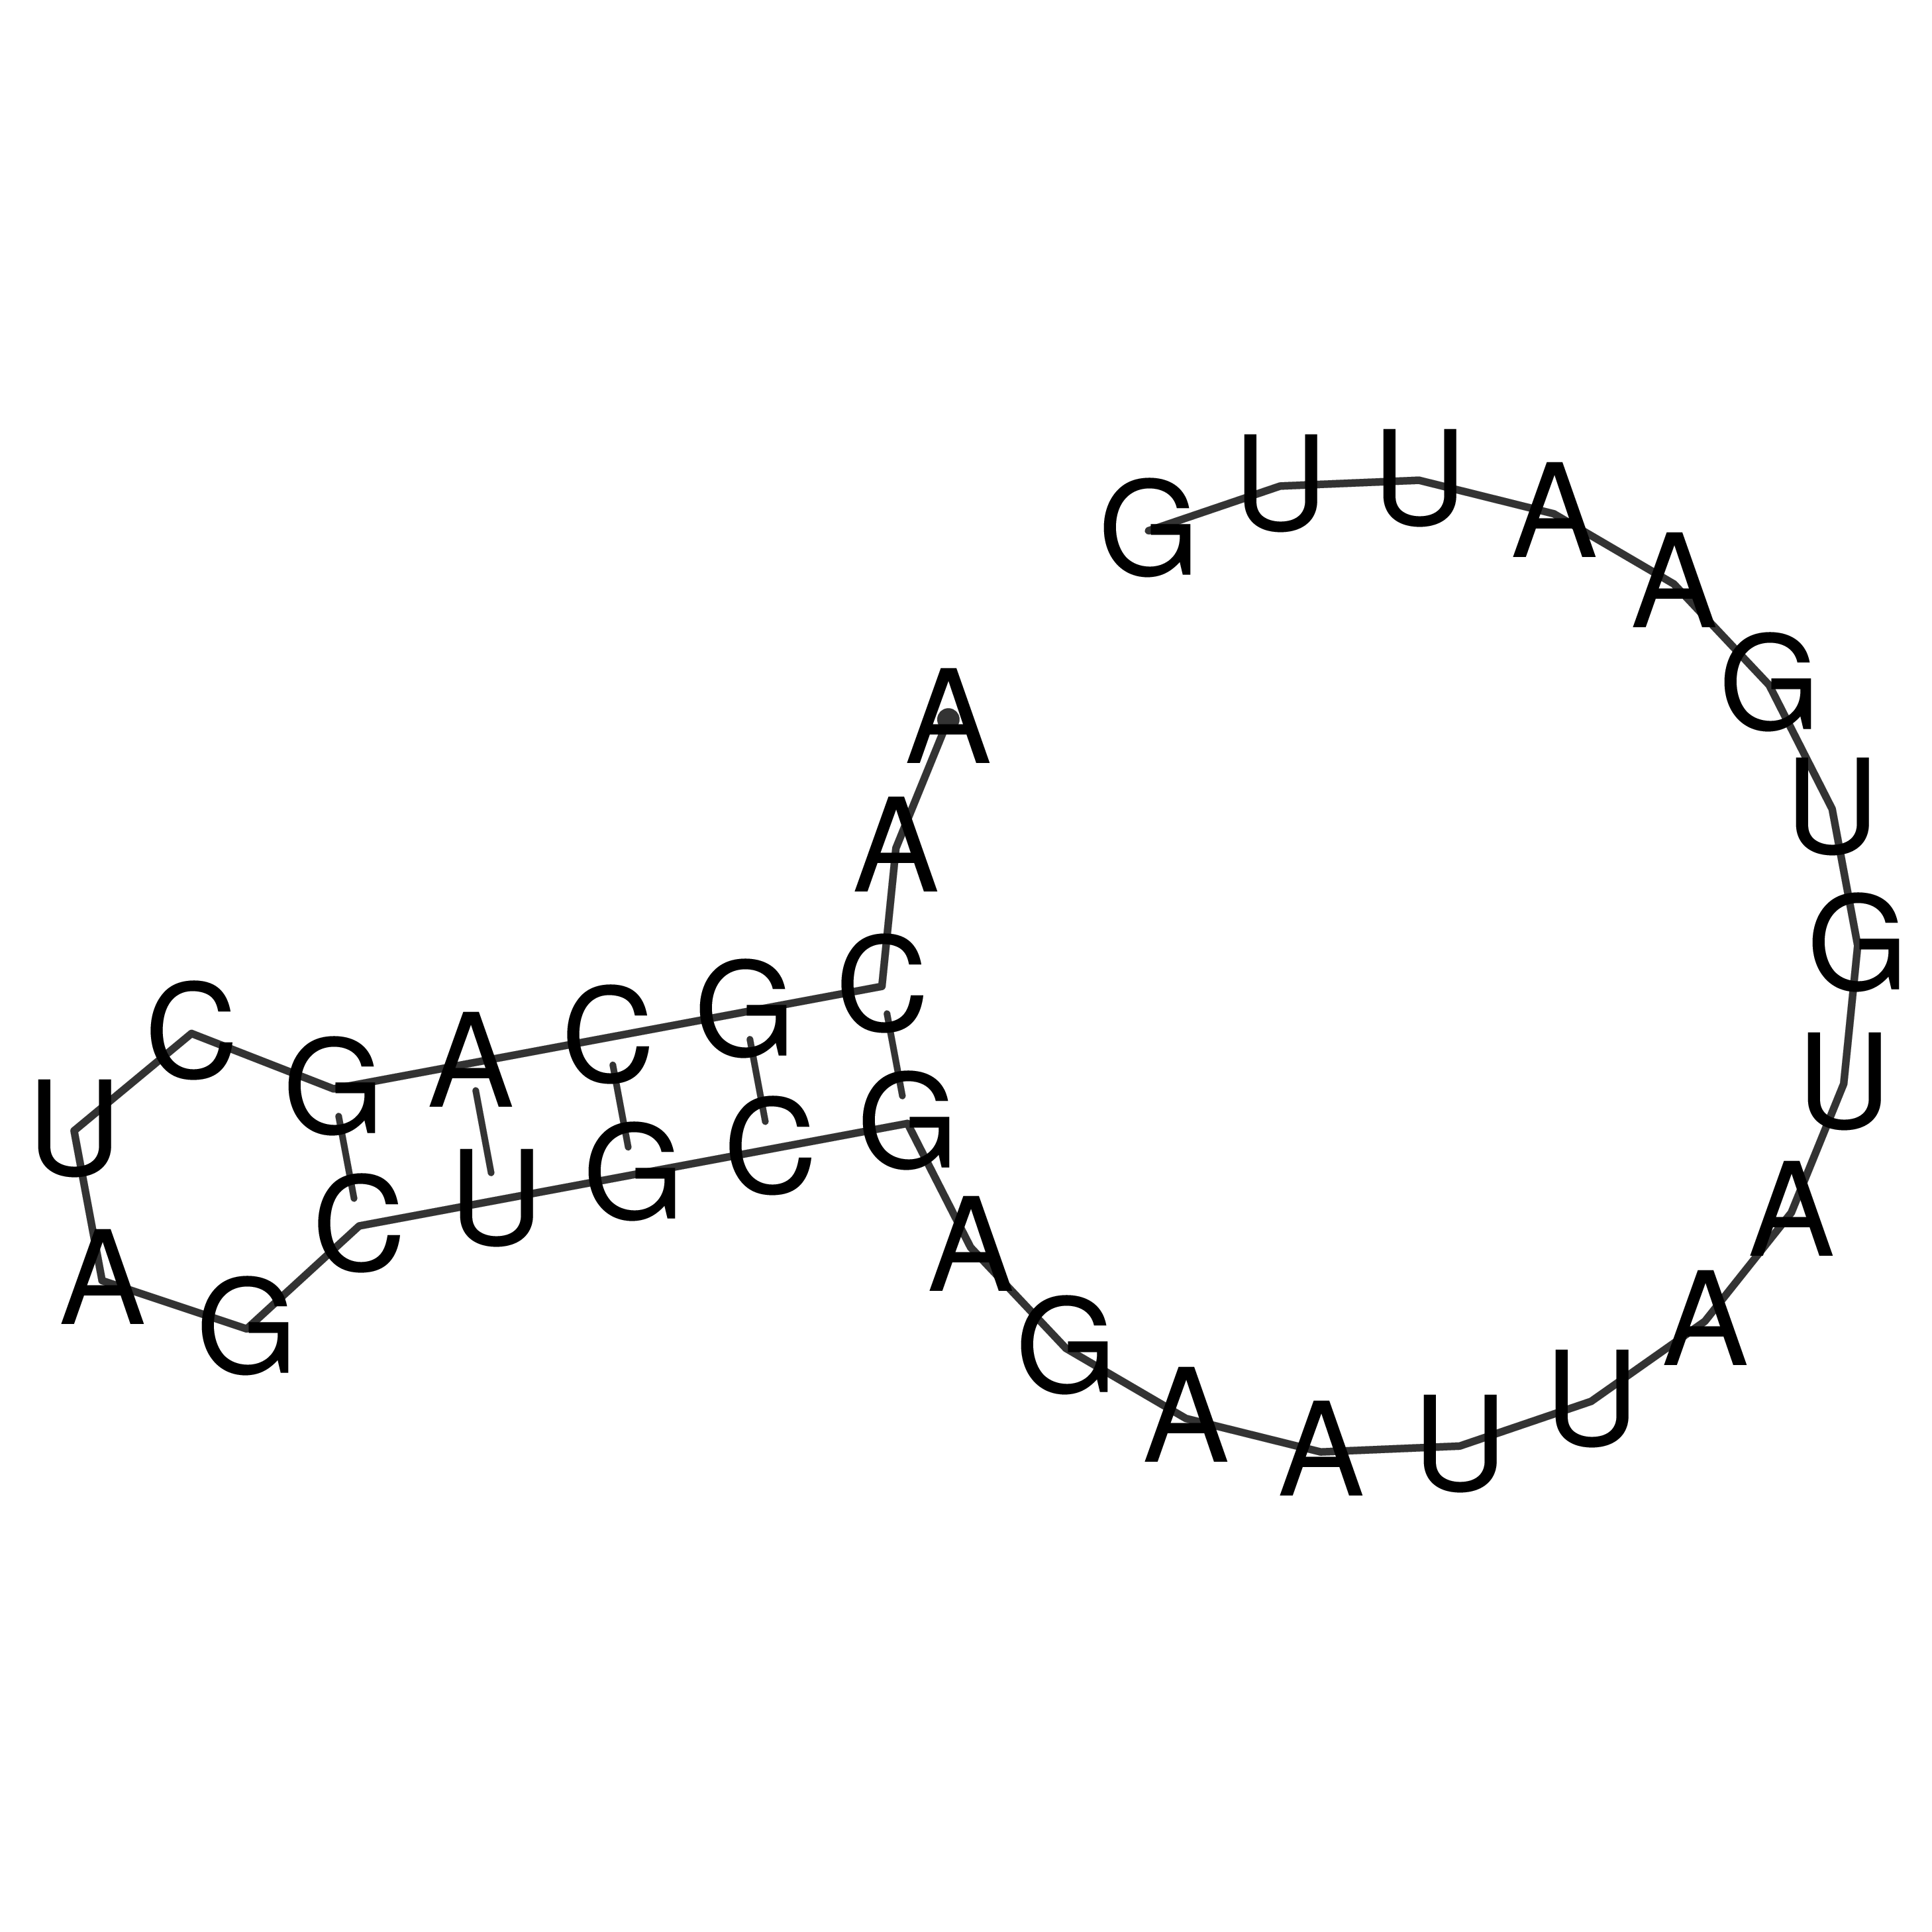



📊 [5-ETS 최상위 Peak 구조 분석]
🎯 최상위 핫스팟 좌표: 2392bp (최대 Score: 484.78)
📈 구간 내 농축 임계값 (Score): 13.45
🧬 데이터 기반 진짜 결합 구간: 2345bp ~ 2397bp (길이: 53bp)
🔍 지지대(Flank) 포함 최종 슬라이싱: 2330bp ~ 2412bp (총 길이: 83bp)
서열: 5'- UCGGCUCGGCGCUGCAGGUGUGGUGGGACUGCUCAGGGGAGUGGUGCAGUGUGAUUCCCGCCGGUUUUGCCUCGCGUGCCCUG -3'

결과 (Dot-Bracket): .......(((((.((((((((((((((((((((((......))).))))......))))))))....))))).)))))))...
Minimum Free Energy (MFE): (-32.90)



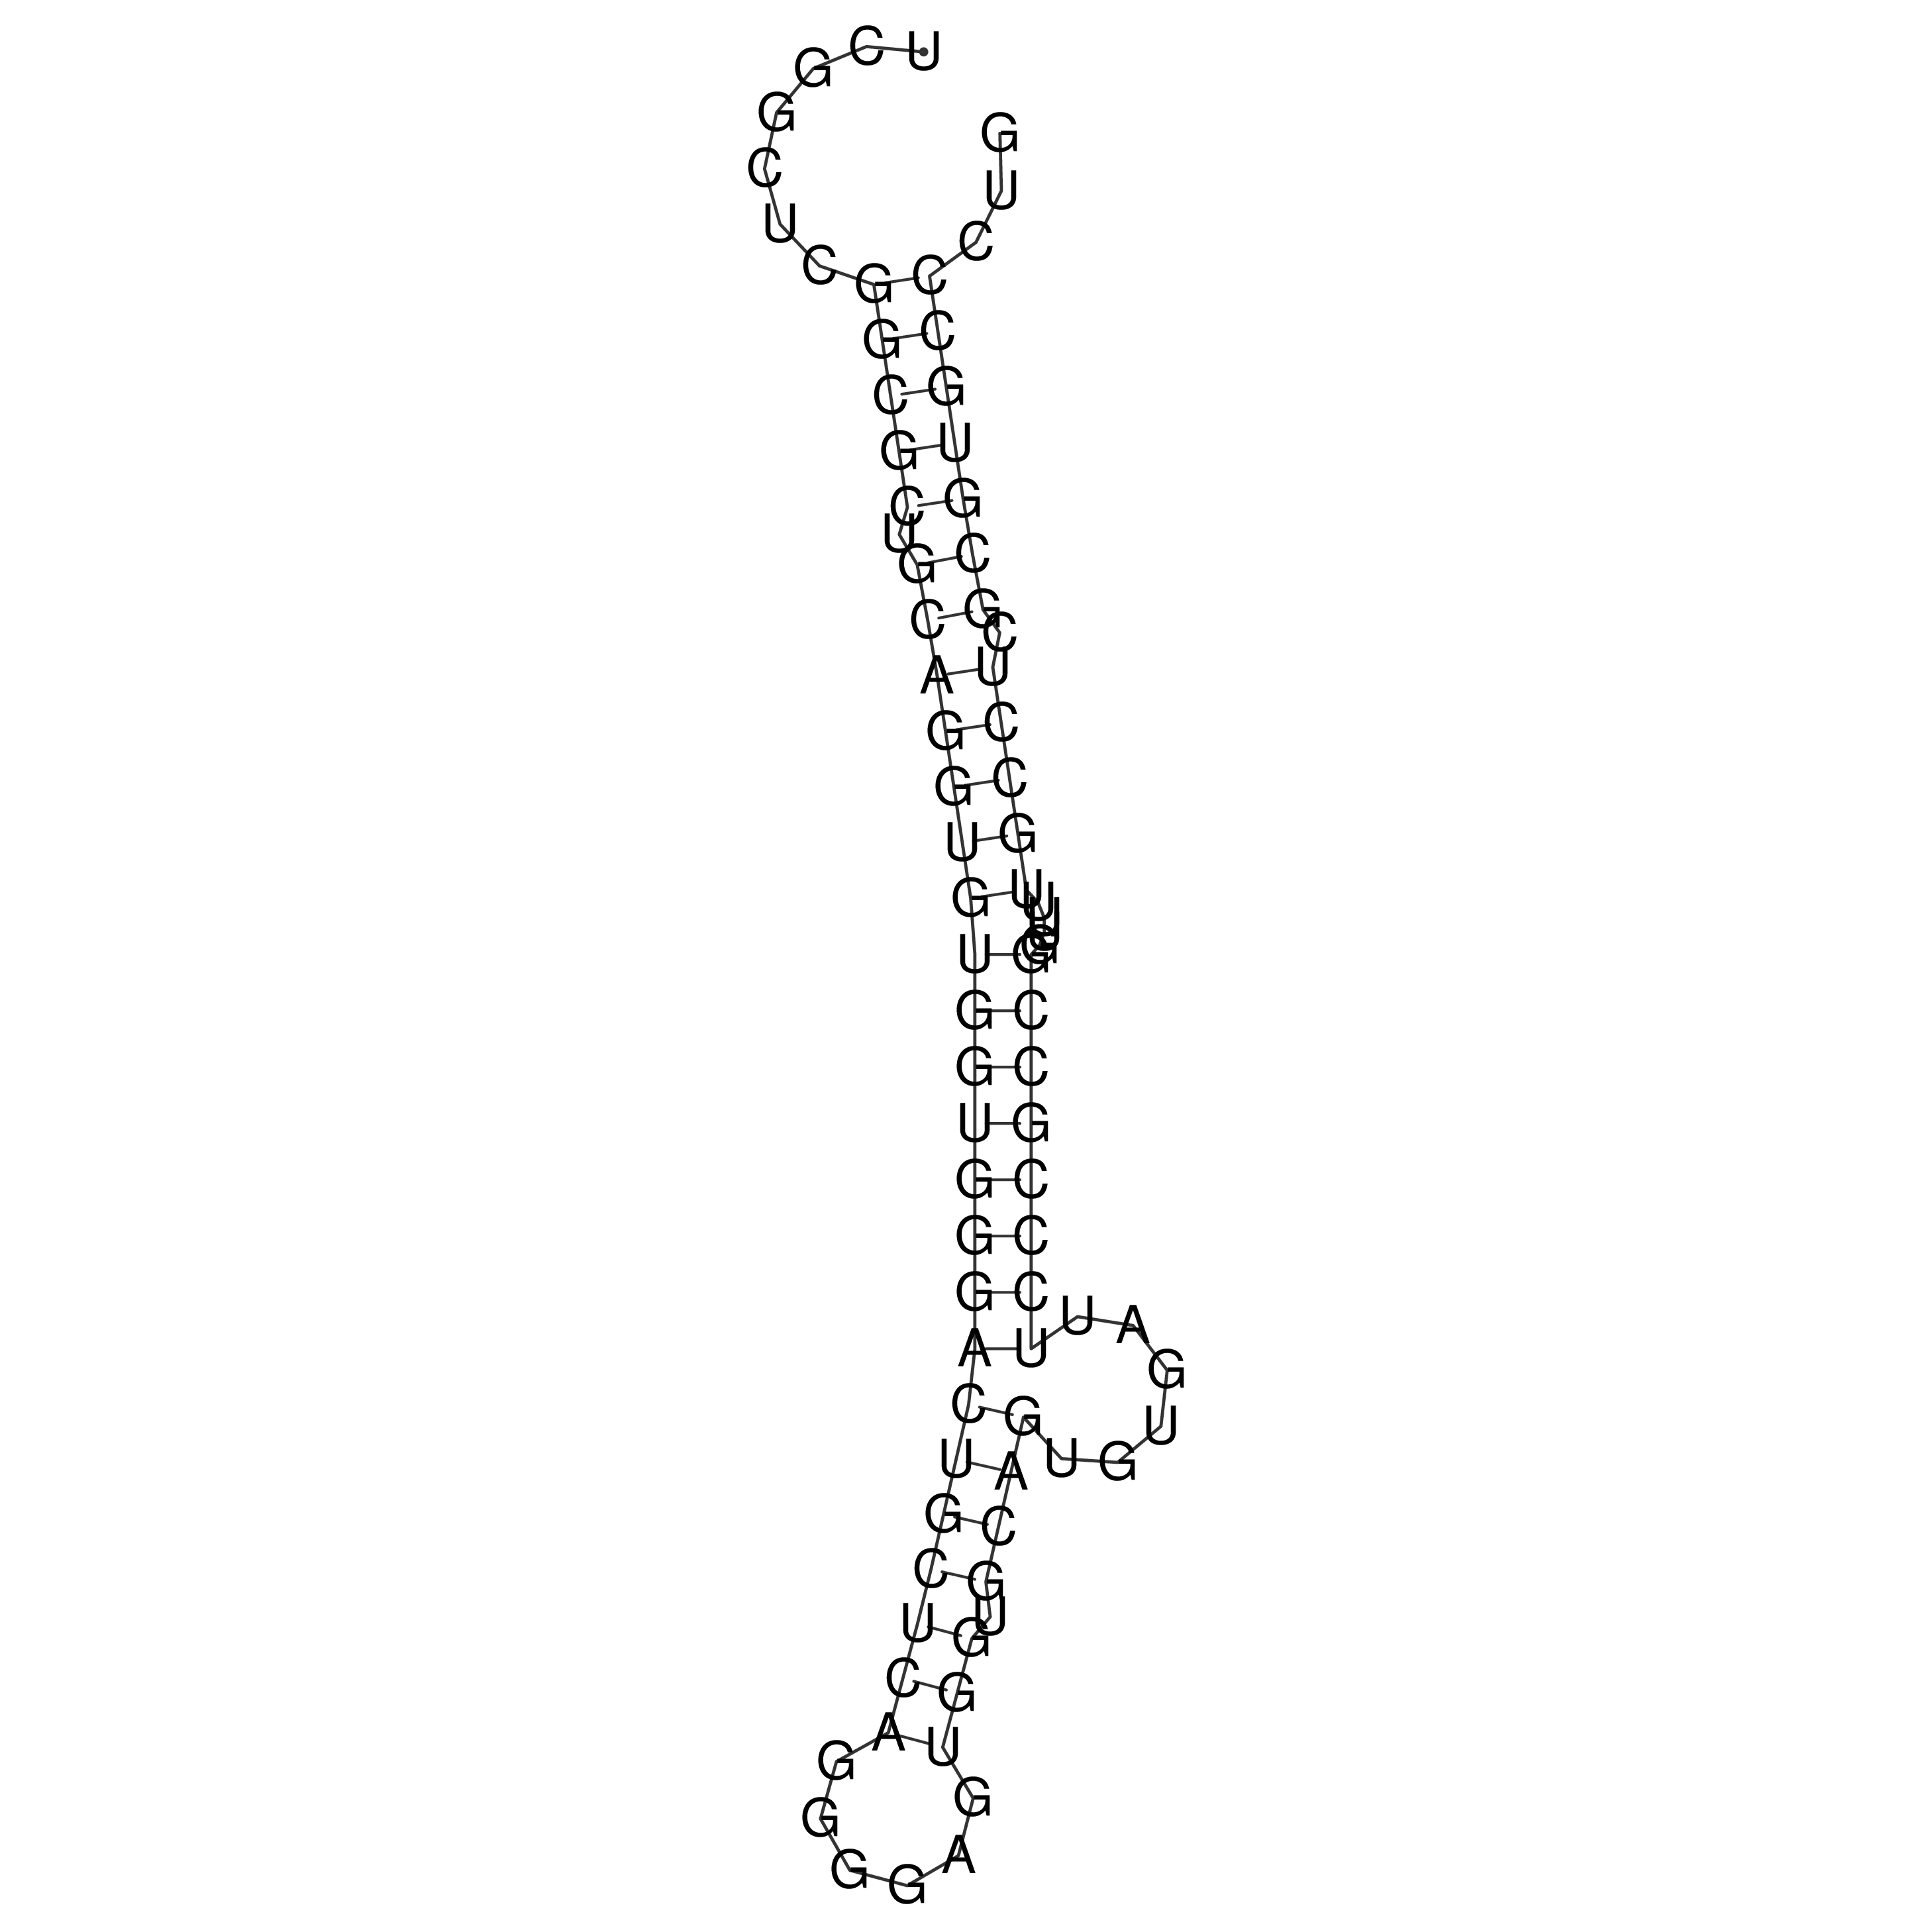



📊 [Full-length rRNA 최상위 Peak 구조 분석]
🎯 최상위 핫스팟 좌표: 24589bp (최대 Score: 1084.69)
📈 구간 내 농축 임계값 (Score): 14.72
🧬 데이터 기반 진짜 결합 구간: 24584bp ~ 24655bp (길이: 72bp)
🔍 지지대(Flank) 포함 최종 슬라이싱: 24572bp ~ 24667bp (총 길이: 96bp)
서열: 5'- CCGAAAUUUCAUGUCUCUCUUCUCUCUCUCUCUCUCUCUCUCUCUCUCUCUCUCUCUCUCUCUCUCUCUCUCUCUCUUUCUUUCUUUCUUACAUUU -3'

결과 (Dot-Bracket): ................................................................................................
Minimum Free Energy (MFE): (  0.00)



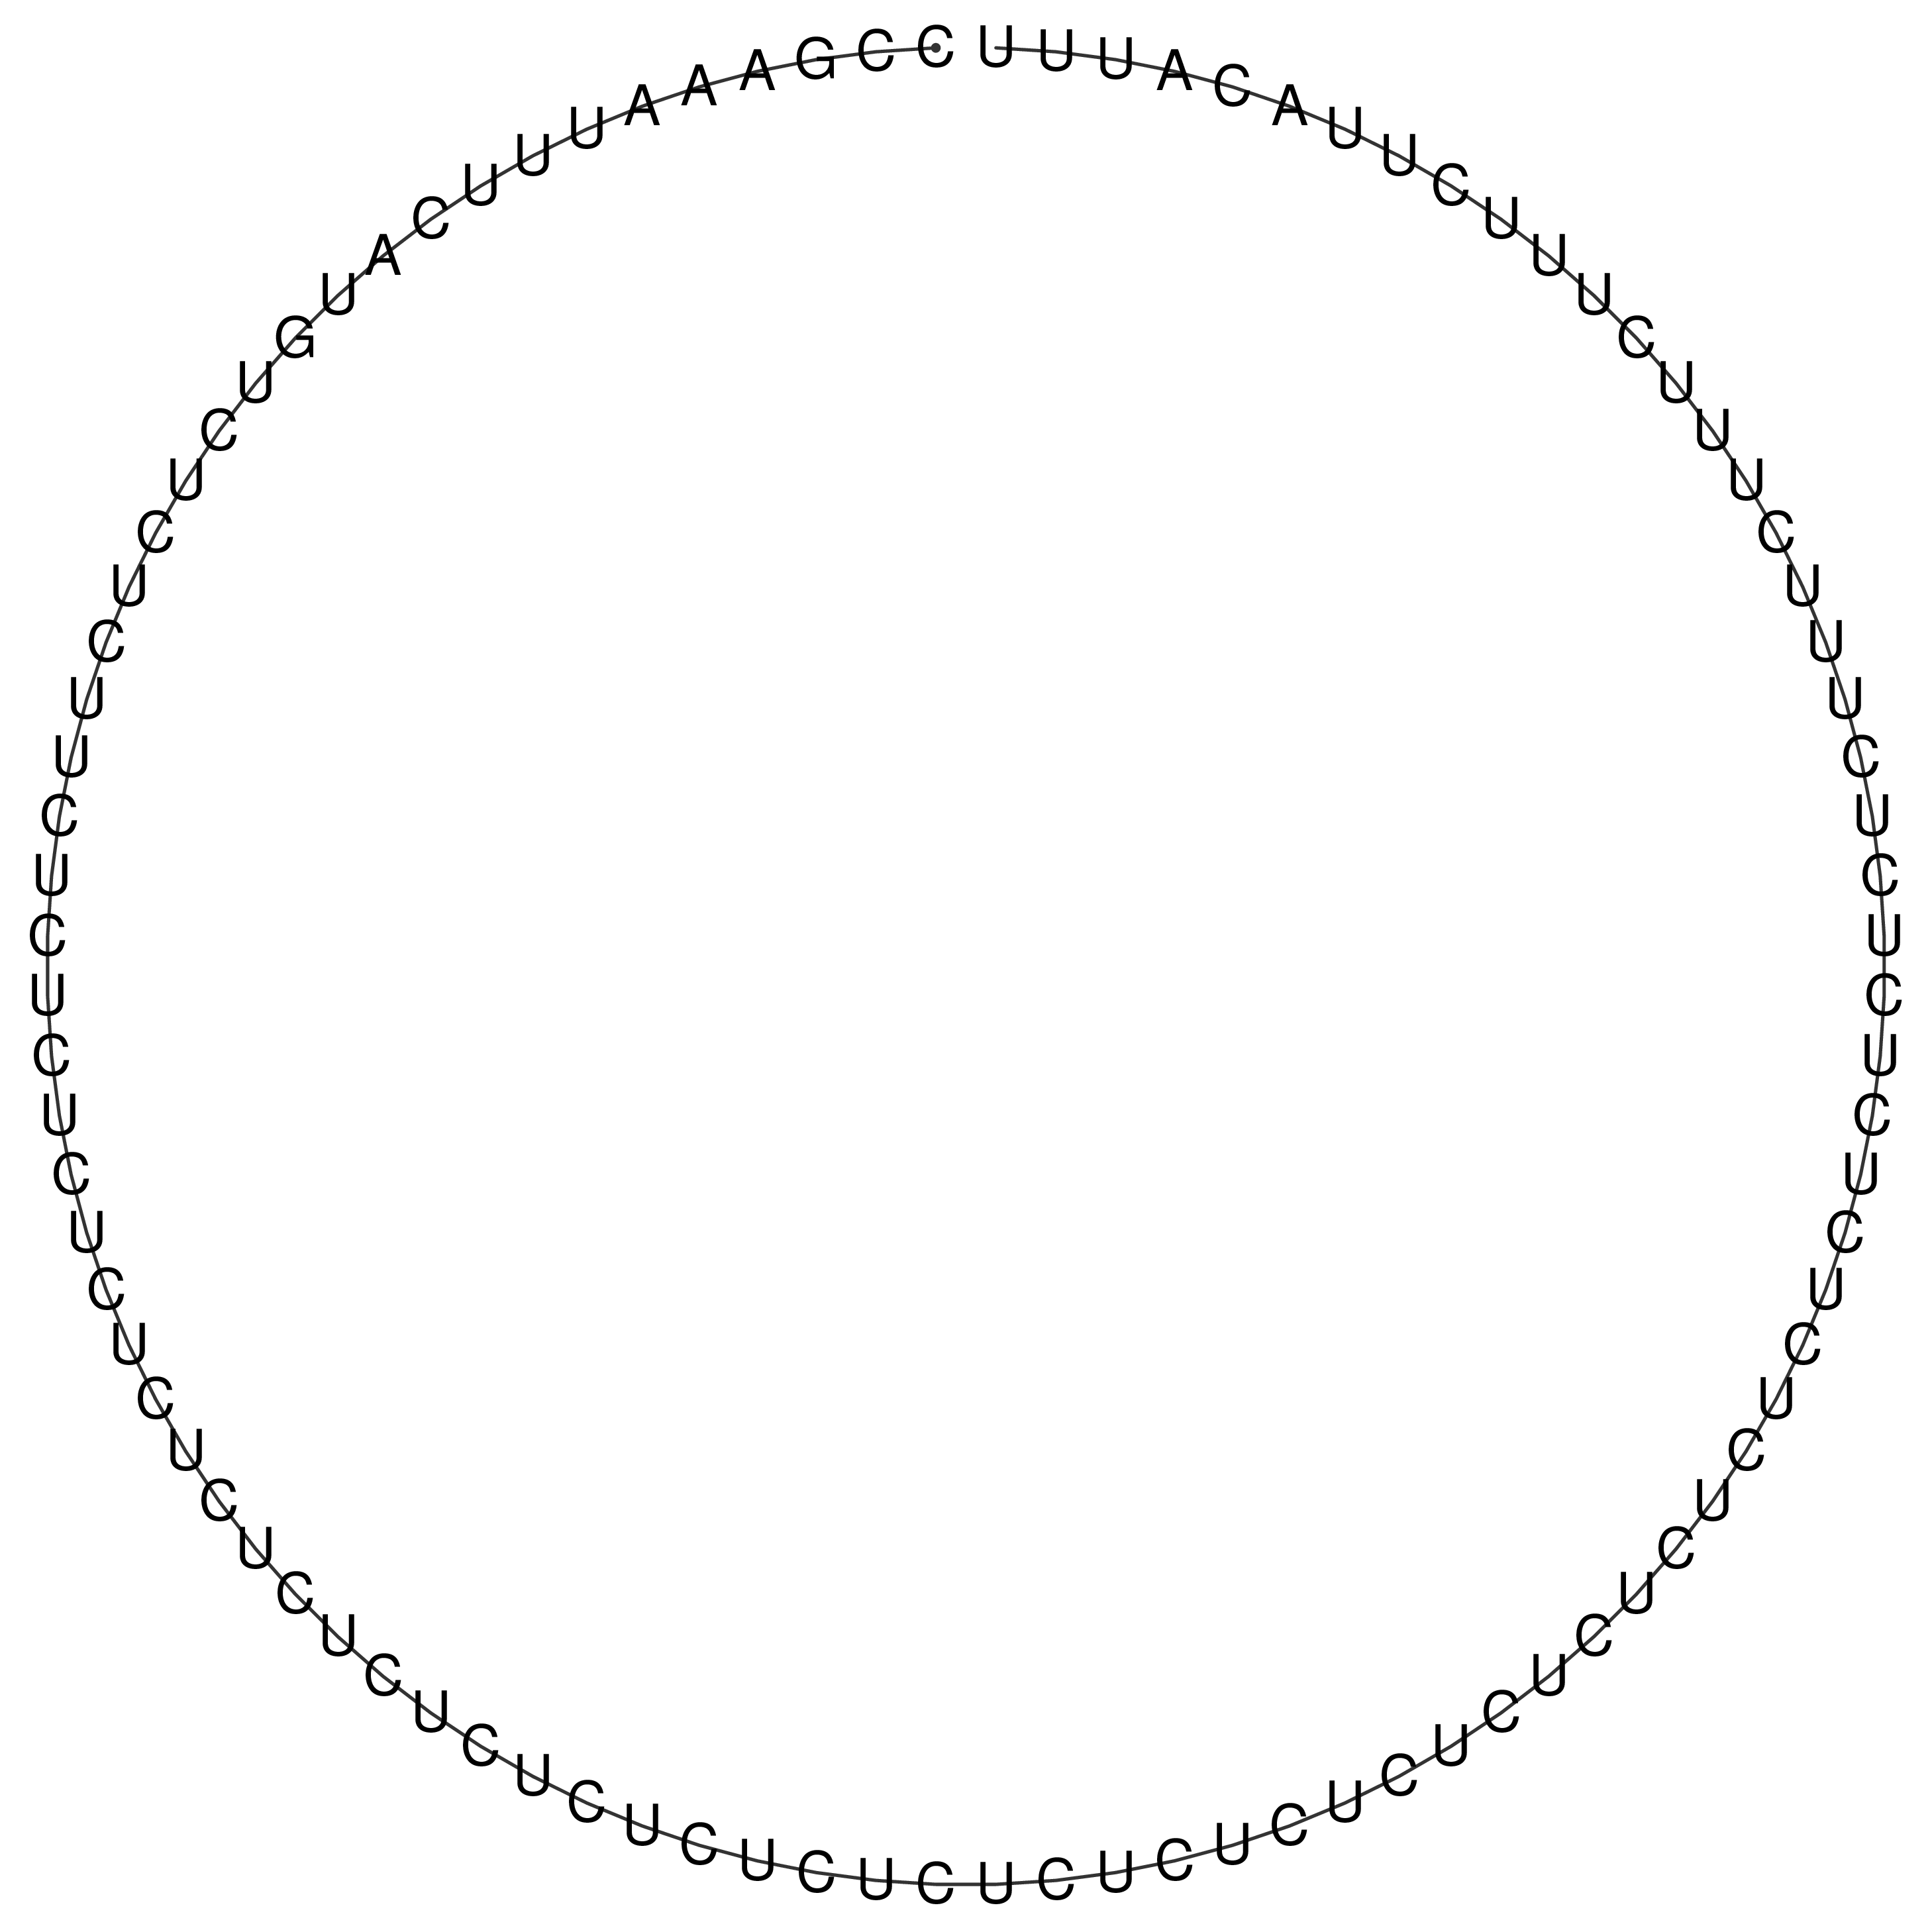

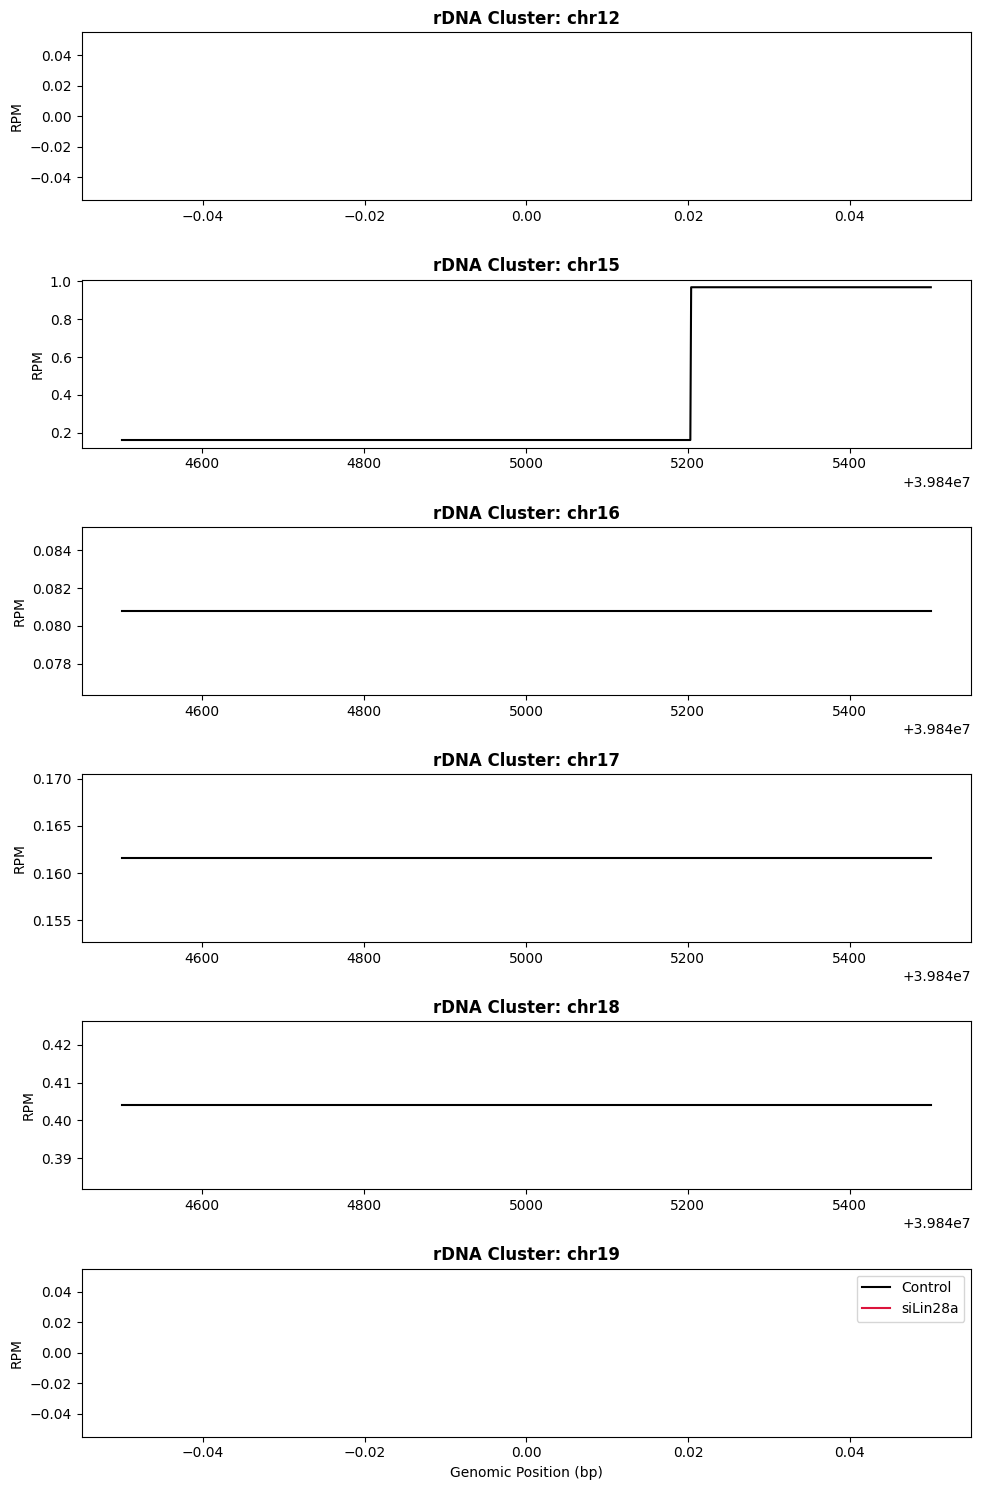

In [53]:
import pysam
import pandas as pd
import matplotlib.pyplot as plt

# 1. 파일 및 대상 염색체 설정
BAM_CONTROL = "/content/binfo1-mywork/RNA-control.bam"
BAM_SILIN28A = "/content/binfo1-mywork/RNA-siLin28a.bam"
# rDNA가 밀집된 주요 염색체들
target_chroms = ['chr12', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19']

# 2. 전역 리드 수 계산 (노멀라이즈 분모)
def get_total_mapped_reads(bam_path):
    samfile = pysam.AlignmentFile(bam_path, "rb")
    total = sum(stat.mapped for stat in samfile.get_index_statistics())
    samfile.close()
    return total

total_ctrl = get_total_mapped_reads(BAM_CONTROL)
total_si = get_total_mapped_reads(BAM_SILIN28A)

# 3. 데이터 추출 함수 (특정 염색체의 핫스팟 중심 1kb 구간)
def get_rpm_profile(bam_path, chrom, center, total_reads):
    samfile = pysam.AlignmentFile(bam_path, "rb")
    window = 500
    data = {}
    for pileup in samfile.pileup(chrom, center-window, center+window, truncate=True):
        pos = pileup.pos + 1
        data[pos] = (pileup.nsegments / total_reads) * 1e6
    samfile.close()
    return data

# 4. 시각화 (Subplot 활용)
fig, axes = plt.subplots(len(target_chroms), 1, figsize=(10, 15), sharex=False)

for i, chrom in enumerate(target_chroms):
    # 각 염색체의 중심 주소 (앞선 분석에서 chr17 확인한 주소 39845000 사용)
    # rDNA는 보통 말단에 위치하므로 동일 주소 활용 가능
    center = 39845000

    profile_ctrl = get_rpm_profile(BAM_CONTROL, chrom, center, total_ctrl)
    profile_si = get_rpm_profile(BAM_SILIN28A, chrom, center, total_si)

    df = pd.DataFrame({'Ctrl': profile_ctrl, 'siLin28a': profile_si})

    axes[i].plot(df.index, df['Ctrl'], color='black', label='Control')
    axes[i].plot(df.index, df['siLin28a'], color='crimson', label='siLin28a')
    axes[i].set_title(f"rDNA Cluster: {chrom}", fontweight='bold')
    axes[i].set_ylabel("RPM")

axes[-1].set_xlabel("Genomic Position (bp)")
plt.tight_layout()
plt.legend()
plt.show()

In [50]:
# 성숙 영역과 스페이서 영역의 카운트 추출 함수 (안전 모드)
def get_domain_read_count_safe(bam_path, ref, start, end):
    samfile = pysam.AlignmentFile(bam_path, "rb")
    count = samfile.count(ref, start-1, end)
    samfile.close()
    return count if count > 0 else 1 # 0으로 나누는 것을 방지하기 위해 최소 1 반환

# 1. 핫스팟 중심 좌표를 기준으로 도메인 재설정
# 아까 찾은 TARGET_CENTER를 활용
center = TARGET_CENTER
mature_coords = (center - 200, center + 50)  # 예시: 18S+5.8S 영역
spacer_coords = (center + 51, center + 300)  # 예시: ITS1 영역

# 2. 안전하게 카운트 계산
ctrl_mature = get_domain_read_count_safe(BAM_CONTROL, REFERENCE_NAME, *mature_coords)
ctrl_spacer = get_domain_read_count_safe(BAM_CONTROL, REFERENCE_NAME, *spacer_coords)

si_mature = get_domain_read_count_safe(BAM_SILIN28A, REFERENCE_NAME, *mature_coords)
si_spacer = get_domain_read_count_safe(BAM_SILIN28A, REFERENCE_NAME, *spacer_coords)

# 3. 계산
ctrl_index = ctrl_spacer / ctrl_mature
si_index = si_spacer / si_mature

print(f"Control Stalling Index: {ctrl_index:.4f}")
print(f"siLin28a Stalling Index: {si_index:.4f}")
print(f"가공 정체율 변화: {si_index / ctrl_index:.4f}배")

Control Stalling Index: 1.4444
siLin28a Stalling Index: 1.0166
가공 정체율 변화: 0.7038배
